In [1]:
!pip install ta xgboost scikit-learn -q

  Preparing metadata (setup.py) ... done


In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ta.trend import EMAIndicator, MACD
from ta.momentum import RSIIndicator, ROCIndicator
from torch.utils.data import Dataset, DataLoader
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import torch.nn as nn
import math

import warnings

warnings.filterwarnings('ignore')
plt.style.use('dark_background')
sns.set_palette("muted")


In [3]:
class KaggleDataPipeline:
    def __init__(self, filepath: str, start_date: str = '2018-01-01'):
        self.filepath = filepath
        self.start_date = start_date
        self.raw_cols = ['Timestamp', 'Open', 'High', 'Low', 'Close', 'Volume']
        self.dtypes = {
            'Open': np.float32,
            'High': np.float32,
            'Low': np.float32,
            'Close': np.float32,
            'Volume': np.float32
        }

    def load_and_clean(self) -> pd.DataFrame:
        df = pd.read_csv(self.filepath, usecols=self.raw_cols, dtype=self.dtypes)
        df.rename(columns={
            'Timestamp': 'timestamp',
            'Open': 'open',
            'High': 'high',
            'Low': 'low',
            'Close': 'close',
            'Volume': 'volume'
        }, inplace=True)
        
        df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')
        df.set_index('timestamp', inplace=True)
        df = df[df.index >= self.start_date]
        
        if not df.index.is_monotonic_increasing:
            df.sort_index(inplace=True)
            
        df = df[~df.index.duplicated(keep='first')]
        df = df.asfreq('1min', method='ffill')
        df.fillna(method='ffill', inplace=True)
        return df

class MarketAuditor:
    @staticmethod
    def apply_winsorization(df: pd.DataFrame, col: str = 'log_return', z_thresh: float = 5.0) -> pd.DataFrame:
        mean_val = df[col].mean()
        std_val = df[col].std()
        upper_bound = mean_val + z_thresh * std_val
        lower_bound = mean_val - z_thresh * std_val
        df[col] = np.clip(df[col], lower_bound, upper_bound)
        return df

    @staticmethod
    def compute_base_signals(df: pd.DataFrame, vol_window: int = 1440) -> pd.DataFrame:
        df['simple_return'] = df['close'].pct_change().astype(np.float32)
        df['log_return'] = np.log(df['close'] / df['close'].shift(1)).astype(np.float32)
        df['rolling_volatility'] = df['log_return'].rolling(window=vol_window).std().astype(np.float32)
        df.replace([np.inf, -np.inf], np.nan, inplace=True)
        df.dropna(inplace=True)
        return df

class TargetGenerator:
    def __init__(self, horizon: int = 15):
        self.horizon = horizon

    def generate(self, df: pd.DataFrame) -> pd.DataFrame:
        df[f'fwd_ret_{self.horizon}m'] = (df['close'].shift(-self.horizon) / df['close']) - 1.0
        df['target_cls'] = np.where(df[f'fwd_ret_{self.horizon}m'] > 0, 1, 0)
        df.dropna(inplace=True)
        df['target_cls'] = df['target_cls'].astype(np.int8)
        df[f'fwd_ret_{self.horizon}m'] = df[f'fwd_ret_{self.horizon}m'].astype(np.float32)
        return df

In [4]:
class FirstPrinciplesEngineer:
    @staticmethod
    def compute_moving_averages(df: pd.DataFrame, col: str = 'close', windows: list = [15, 50]) -> pd.DataFrame:
        for w in windows:
            df[f'sma_{w}'] = df[col].rolling(window=w).mean().astype(np.float32)
            df[f'ema_{w}'] = df[col].ewm(span=w, adjust=False).mean().astype(np.float32)
        return df

    @staticmethod
    def compute_momentum(df: pd.DataFrame, col: str = 'close', windows: list = [5, 15, 60]) -> pd.DataFrame:
        for w in windows:
            df[f'mom_{w}'] = (df[col] / df[col].shift(w) - 1.0).astype(np.float32)
        return df

    @staticmethod
    def compute_rsi(df: pd.DataFrame, col: str = 'close', window: int = 14) -> pd.DataFrame:
        delta = df[col].diff()
        up = delta.clip(lower=0)
        down = -1 * delta.clip(upper=0)
        ema_up = up.ewm(com=window-1, adjust=False).mean()
        ema_down = down.ewm(com=window-1, adjust=False).mean()
        rs = ema_up / ema_down
        df['rsi'] = (100.0 - (100.0 / (1.0 + rs))).astype(np.float32)
        return df

    @staticmethod
    def compute_macd(df: pd.DataFrame, col: str = 'close', fast: int = 12, slow: int = 26, signal: int = 9) -> pd.DataFrame:
        ema_fast = df[col].ewm(span=fast, adjust=False).mean()
        ema_slow = df[col].ewm(span=slow, adjust=False).mean()
        df['macd_line'] = (ema_fast - ema_slow).astype(np.float32)
        df['macd_signal'] = df['macd_line'].ewm(span=signal, adjust=False).mean().astype(np.float32)
        df['macd_hist'] = (df['macd_line'] - df['macd_signal']).astype(np.float32)
        return df

    @staticmethod
    def compute_zscore(df: pd.DataFrame, col: str = 'close', window: int = 60) -> pd.DataFrame:
        rolling_mean = df[col].rolling(window=window).mean()
        rolling_std = df[col].rolling(window=window).std()
        df['z_score'] = ((df[col] - rolling_mean) / rolling_std).astype(np.float32)
        return df

In [5]:
FILE_PATH = '/kaggle/input/datasets/mczielinski/bitcoin-historical-data/btcusd_1-min_data.csv'
START_DATE = '2018-01-01'
HORIZON_MINUTES = 15

pipeline = KaggleDataPipeline(FILE_PATH, START_DATE)
df_raw = pipeline.load_and_clean()

df_master = MarketAuditor.compute_base_signals(df_raw, vol_window=1440)
df_master = MarketAuditor.apply_winsorization(df_master, col='log_return', z_thresh=5.0)

target_engine = TargetGenerator(horizon=HORIZON_MINUTES)
df_master = target_engine.generate(df_master)

engineer = FirstPrinciplesEngineer()
df_master = engineer.compute_moving_averages(df_master, windows=[15, 50])
df_master = engineer.compute_momentum(df_master, windows=[5, 15, 60])
df_master = engineer.compute_rsi(df_master, window=14)
df_master = engineer.compute_macd(df_master, fast=12, slow=26, signal=9)
df_master = engineer.compute_zscore(df_master, window=60)

df_master.dropna(inplace=True)

print(f"Final Data Shape (Post-2018): {df_master.shape}")
print(df_master[['close', 'log_return', 'rsi', 'macd_hist', 'z_score', 'target_cls']].tail())

Final Data Shape (Post-2018): (4447320, 22)
                            close  log_return        rsi  macd_hist   z_score  \
timestamp                                                                       
2026-06-18 00:07:00  64556.730469    0.000106  69.219795  11.732630  1.937611   
2026-06-18 00:08:00  64514.019531   -0.000662  58.877903   7.585762  1.370644   
2026-06-18 00:09:00  64548.660156    0.000537  63.624767   6.525587  1.766751   
2026-06-18 00:10:00  64572.968750    0.000377  66.543350   6.781425  2.015895   
2026-06-18 00:11:00  64561.898438   -0.000171  64.023972   5.575455  1.819733   

                     target_cls  
timestamp                        
2026-06-18 00:07:00           1  
2026-06-18 00:08:00           1  
2026-06-18 00:09:00           1  
2026-06-18 00:10:00           0  
2026-06-18 00:11:00           0  


In [6]:
class ProductionFeatureEngine:
    @staticmethod
    def apply_ta_features(df: pd.DataFrame) -> pd.DataFrame:
        df['ema_15'] = EMAIndicator(close=df['close'], window=15).ema_indicator().astype(np.float32)
        df['ema_60'] = EMAIndicator(close=df['close'], window=60).ema_indicator().astype(np.float32)
        df['rsi_14'] = RSIIndicator(close=df['close'], window=14).rsi().astype(np.float32)
        
        macd = MACD(close=df['close'], window_fast=12, window_slow=26, window_sign=9)
        df['macd_line'] = macd.macd().astype(np.float32)
        df['macd_signal'] = macd.macd_signal().astype(np.float32)
        df['macd_hist'] = macd.macd_diff().astype(np.float32)
        
        df['mom_15'] = ROCIndicator(close=df['close'], window=15).roc().astype(np.float32)
        
        rolling_mean = df['close'].rolling(window=60).mean()
        rolling_std = df['close'].rolling(window=60).std()
        df['z_score'] = ((df['close'] - rolling_mean) / rolling_std).astype(np.float32)
        
        df.dropna(inplace=True)
        return df

df_master = ProductionFeatureEngine.apply_ta_features(df_master)
print(f"Phase 4 Complete. Master DataFrame Shape: {df_master.shape}")

Phase 4 Complete. Master DataFrame Shape: (4447261, 24)


In [7]:
class CryptoSequenceDataset(Dataset):
    def __init__(self, df: pd.DataFrame, target_col: str, exclude_cols: list, sequence_length: int = 60):
        self.sequence_length = sequence_length
        self.feature_cols = [col for col in df.columns if col not in exclude_cols + [target_col]]
        
        self.X_data = df[self.feature_cols].values.astype(np.float32)
        self.y_data = df[target_col].values.astype(np.int8)

    def __len__(self):
        return len(self.X_data) - self.sequence_length

    def __getitem__(self, idx):
        X_seq = self.X_data[idx : idx + self.sequence_length]
        y_label = self.y_data[idx + self.sequence_length - 1]
        return torch.tensor(X_seq), torch.tensor(y_label)

SEQ_LENGTH = 60 
TARGET_COLUMN = 'target_cls'
EXCLUDE_COLUMNS = ['fwd_ret_15m', 'simple_return'] 

pytorch_dataset = CryptoSequenceDataset(
    df=df_master, 
    target_col=TARGET_COLUMN, 
    exclude_cols=EXCLUDE_COLUMNS,
    sequence_length=SEQ_LENGTH
)

sample_loader = DataLoader(pytorch_dataset, batch_size=2048, shuffle=False)
sample_X, sample_y = next(iter(sample_loader))

print(f"Phase 5 Complete. RAM is safe.")
print(f"Dataset Length: {len(pytorch_dataset)} sequences available.")
print(f"Sample Batch X Shape: {sample_X.shape}")
print(f"Sample Batch y Shape: {sample_y.shape}")

Phase 5 Complete. RAM is safe.
Dataset Length: 4447201 sequences available.
Sample Batch X Shape: torch.Size([2048, 60, 21])
Sample Batch y Shape: torch.Size([2048])


In [8]:
class BaselineEvaluator:
    def __init__(self):
        self.model = XGBClassifier(
            n_estimators=100, 
            learning_rate=0.05, 
            max_depth=4, 
            subsample=0.8,
            random_state=42,
            n_jobs=-1,
            tree_method='hist'
        )

    def chronological_split(self, X: np.ndarray, y: np.ndarray, test_size: float = 0.2):
        split_idx = int(len(X) * (1 - test_size))
        X_train, X_test = X[:split_idx], X[split_idx:]
        y_train, y_test = y[:split_idx], y[split_idx:]
        return X_train, X_test, y_train, y_test

    def evaluate(self, df: pd.DataFrame, target_col: str, exclude_cols: list) -> dict:
        feature_cols = [col for col in df.columns if col not in exclude_cols + [target_col]]
        X = df[feature_cols].values.astype(np.float32)
        y = df[target_col].values.astype(np.int8)
        
        X_train, X_test, y_train, y_test = self.chronological_split(X, y)
        
        self.model.fit(X_train, y_train)
        
        y_pred = self.model.predict(X_test)
        y_prob = self.model.predict_proba(X_test)[:, 1]
        
        metrics = {
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, zero_division=0),
            'Recall': recall_score(y_test, y_pred, zero_division=0),
            'F1 Score': f1_score(y_test, y_pred, zero_division=0),
            'ROC-AUC': roc_auc_score(y_test, y_prob)
        }
        return metrics

baseline_engine = BaselineEvaluator()
baseline_metrics = baseline_engine.evaluate(df_master, TARGET_COLUMN, EXCLUDE_COLUMNS)

print("--- BASELINE METRICS (XGBoost) ---")
for metric, value in baseline_metrics.items():
    print(f"{metric}: {value:.4f}")

--- BASELINE METRICS (XGBoost) ---
Accuracy: 0.5159
Precision: 0.5220
Recall: 0.3492
F1 Score: 0.4185
ROC-AUC: 0.5232


In [9]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pe[:, :x.size(1)]

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model: int, num_heads: int):
        super().__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        self.head_dim = d_model // num_heads

        self.q_linear = nn.Linear(d_model, d_model)
        self.k_linear = nn.Linear(d_model, d_model)
        self.v_linear = nn.Linear(d_model, d_model)
        self.out_linear = nn.Linear(d_model, d_model)

    def forward(self, x: torch.Tensor):
        batch_size, seq_len, _ = x.size()

        Q = self.q_linear(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        K = self.k_linear(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        V = self.v_linear(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.head_dim)
        attn_weights = torch.softmax(scores, dim=-1)
        
        context = torch.matmul(attn_weights, V)
        context = context.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)
        output = self.out_linear(context)

        return output, attn_weights

class TransformerBlock(nn.Module):
    def __init__(self, d_model: int, num_heads: int, ff_dim: int, dropout: float = 0.1):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model)
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor):
        attn_out, attn_weights = self.attention(x)
        x = self.norm1(x + self.dropout(attn_out))
        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_out))
        return x, attn_weights

class GlassBoxTransformer(nn.Module):
    def __init__(self, input_dim: int, d_model: int, num_heads: int, num_layers: int, ff_dim: int, dropout: float = 0.1):
        super().__init__()
        self.input_projection = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        
        self.layers = nn.ModuleList([
            TransformerBlock(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])
        
        self.norm = nn.LayerNorm(d_model)
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 1)
        )

    def forward(self, x: torch.Tensor):
        x = self.input_projection(x)
        x = self.pos_encoder(x)
        
        layer_attentions = []
        for layer in self.layers:
            x, attn_weights = layer(x)
            layer_attentions.append(attn_weights)
            
        x = self.norm(x)
        x_last = x[:, -1, :]
        logits = self.classifier(x_last)
        
        return logits, layer_attentions

In [10]:
INPUT_DIM = sample_X.shape[-1]
D_MODEL = 64
NUM_HEADS = 4
NUM_LAYERS = 2
FF_DIM = 128
DROPOUT = 0.2

model = GlassBoxTransformer(
    input_dim=INPUT_DIM,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    ff_dim=FF_DIM,
    dropout=DROPOUT
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

test_batch_X = sample_X.to(device)

model.eval()
with torch.no_grad():
    logits, attentions = model(test_batch_X)

print(f"Device: {device}")
print(f"Model Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")
print(f"Input Batch Shape: {test_batch_X.shape}")
print(f"Output Logits Shape: {logits.shape}")
print(f"Number of Attention Layers Extracted: {len(attentions)}")
print(f"Attention Heatmap Shape (Layer 1): {attentions[0].shape}")

Device: cpu
Model Parameters: 70593
Input Batch Shape: torch.Size([2048, 60, 21])
Output Logits Shape: torch.Size([2048, 1])
Number of Attention Layers Extracted: 2
Attention Heatmap Shape (Layer 1): torch.Size([2048, 4, 60, 60])


In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import numpy as np
from tqdm.auto import tqdm

class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = np.inf
        self.early_stop = False
        self.best_state = None

    def __call__(self, val_loss: float, model: nn.Module):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_state = model.state_dict()
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

class GlassBoxTrainer:
    def __init__(self, model: nn.Module, device: torch.device):
        self.model = model.to(device)
        self.device = device
        self.criterion = nn.BCEWithLogitsLoss()
        self.optimizer = optim.AdamW(self.model.parameters(), lr=1e-4, weight_decay=1e-3)
        self.early_stopping = EarlyStopping(patience=5)

    def _calculate_accuracy(self, logits: torch.Tensor, labels: torch.Tensor) -> float:
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()
        correct = (preds.squeeze() == labels).sum().item()
        return correct / len(labels)

    def train_epoch(self, loader: DataLoader, epoch_pbar) -> tuple:
        self.model.train()
        total_loss = 0.0
        total_acc = 0.0
        
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(self.device)
            y_batch = y_batch.to(self.device).float()
            
            self.optimizer.zero_grad()
            
            logits, _ = self.model(X_batch)
            loss = self.criterion(logits.squeeze(), y_batch)
            
            loss.backward()
            nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.optimizer.step()
            
            total_loss += loss.item()
            total_acc += self._calculate_accuracy(logits, y_batch)
            
            epoch_pbar.update(1)
            epoch_pbar.set_postfix({'T_Loss_Live': f"{total_loss / (epoch_pbar.n):.4f}"})
            
        return total_loss / len(loader), total_acc / len(loader)

    def evaluate(self, loader: DataLoader, epoch_pbar) -> tuple:
        self.model.eval()
        total_loss = 0.0
        total_acc = 0.0
        
        with torch.no_grad():
            for X_batch, y_batch in loader:
                X_batch = X_batch.to(self.device)
                y_batch = y_batch.to(self.device).float()
                
                logits, _ = self.model(X_batch)
                loss = self.criterion(logits.squeeze(), y_batch)
                
                total_loss += loss.item()
                total_acc += self._calculate_accuracy(logits, y_batch)
                
                epoch_pbar.update(1)
                
        return total_loss / len(loader), total_acc / len(loader)

    def fit(self, train_loader: DataLoader, val_loader: DataLoader, epochs: int = 50):
        total_batches = len(train_loader) + len(val_loader)
        
        for epoch in range(epochs):
            with tqdm(total=total_batches, desc=f"Epoch {epoch+1:02d}/{epochs}", unit="batch", leave=True) as pbar:
                train_loss, train_acc = self.train_epoch(train_loader, pbar)
                val_loss, val_acc = self.evaluate(val_loader, pbar)
                
                pbar.set_postfix({
                    'T_Loss': f"{train_loss:.4f}", 
                    'V_Loss': f"{val_loss:.4f}", 
                    'V_Acc': f"{val_acc:.4f}"
                })
            
            self.early_stopping(val_loss, self.model)
            if self.early_stopping.early_stop:
                print(f"\n[!] Early stopping triggered at epoch {epoch+1}.")
                self.model.load_state_dict(self.early_stopping.best_state)
                break

In [12]:
dataset_size = len(pytorch_dataset)
train_size = int(0.8 * dataset_size)

train_indices = list(range(train_size))
val_indices = list(range(train_size, dataset_size))

train_dataset = Subset(pytorch_dataset, train_indices)
val_dataset = Subset(pytorch_dataset, val_indices)

train_loader = DataLoader(train_dataset, batch_size=512, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)

trainer = GlassBoxTrainer(model=model, device=device)

print("--- STARTING TRANSFORMER TRAINING ---")
print(f"Train Sequences: {len(train_dataset)}")
print(f"Validation Sequences: {len(val_dataset)}\n")

trainer.fit(train_loader, val_loader, epochs=2)

--- STARTING TRANSFORMER TRAINING ---
Train Sequences: 3557760
Validation Sequences: 889441



Epoch 01/2:   0%|          | 0/8687 [00:00<?, ?batch/s]

Epoch 02/2:   0%|          | 0/8687 [00:00<?, ?batch/s]

In [13]:
class GlassBoxVisualizer:
    @staticmethod
    def extract_sequence_data(x_batch: torch.Tensor, active_features: list, feature_name: str = 'close') -> np.ndarray:
        try:
            f_idx = active_features.index(feature_name)
        except ValueError:
            f_idx = 0 
        return x_batch[0, :, f_idx].cpu().numpy()

    @staticmethod
    def plot_temporal_attention(
        model: torch.nn.Module, 
        x_batch: torch.Tensor, 
        y_batch: torch.Tensor, 
        active_features: list, 
        layer_idx: int = -1, 
        head_idx: int = 0
    ):
        model.eval()
        with torch.no_grad():
            logits, attentions = model(x_batch)
            
        probs = torch.sigmoid(logits).cpu().numpy()
        preds = (probs > 0.5).astype(int)
        actuals = y_batch.cpu().numpy()
        
        attn_matrix = attentions[layer_idx][0, head_idx].cpu().numpy()
        prices = GlassBoxVisualizer.extract_sequence_data(x_batch, active_features, 'close')
        
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), gridspec_kw={'height_ratios': [1, 3]})
        
        ax1.plot(prices, color='cyan', linewidth=2)
        ax1.set_title(f"Sequence Price Dynamics | Target: {actuals[0]} | Prediction: {preds[0][0]} (Conf: {probs[0][0]:.2f})", fontsize=14)
        ax1.set_xlim(0, len(prices)-1)
        ax1.grid(True, alpha=0.2)
        
        sns.heatmap(attn_matrix, cmap='inferno', ax=ax2, cbar=True)
        ax2.set_title(f"Self-Attention Heatmap (Transformer Layer: {layer_idx}, Attention Head: {head_idx})", fontsize=14)
        ax2.set_xlabel("Attending To (Key Time Step)", fontsize=12)
        ax2.set_ylabel("Current Step (Query Time Step)", fontsize=12)
        
        plt.tight_layout()
        plt.show()

--- RENDERING GLASS BOX ATTENTION DYNAMICS ---


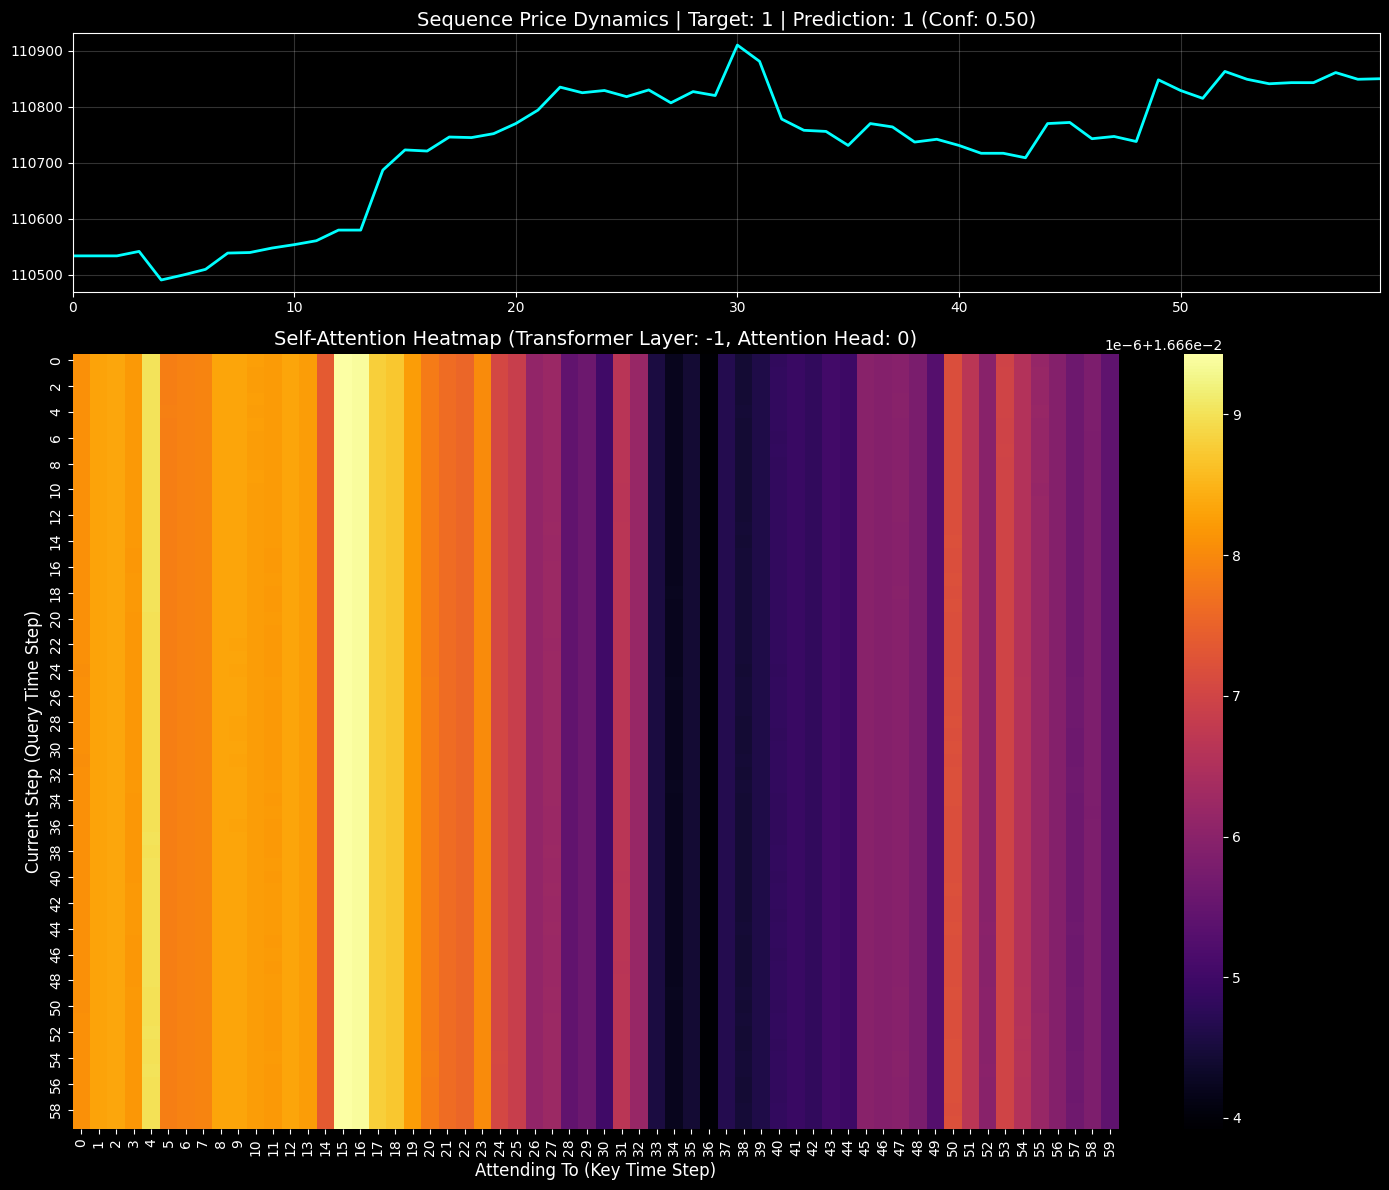

In [14]:
sample_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=True)
test_X, test_y = next(iter(sample_loader))

test_X = test_X.to(device)
test_y = test_y.to(device)

active_features = pytorch_dataset.feature_cols

print("--- RENDERING GLASS BOX ATTENTION DYNAMICS ---")

GlassBoxVisualizer.plot_temporal_attention(
    model=model,
    x_batch=test_X,
    y_batch=test_y,
    active_features=active_features,
    layer_idx=-1, 
    head_idx=0     
)

In [15]:
class PositionalEncodingNative(nn.Module):
    def __init__(self, d_model: int, max_len: int = 5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pe[:, :x.size(1)]

class ProductionTransformer(nn.Module):
    def __init__(self, input_dim: int, d_model: int, num_heads: int, num_layers: int, ff_dim: int, dropout: float = 0.1):
        super().__init__()
        self.input_projection = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncodingNative(d_model)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=num_heads, 
            dim_feedforward=ff_dim, 
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        self.norm = nn.LayerNorm(d_model)
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 1)
        )

    def forward(self, x: torch.Tensor):
        x = self.input_projection(x)
        x = self.pos_encoder(x)
        
        x = self.transformer_encoder(x)
        
        x = self.norm(x)
        x_last = x[:, -1, :]
        logits = self.classifier(x_last)
        
        return logits

In [16]:
INPUT_DIM = active_features.index(active_features[-1]) + 1 if 'active_features' in locals() else sample_X.shape[-1]
D_MODEL = 64
NUM_HEADS = 4
NUM_LAYERS = 2
FF_DIM = 128
DROPOUT = 0.2

prod_model = ProductionTransformer(
    input_dim=INPUT_DIM,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    ff_dim=FF_DIM,
    dropout=DROPOUT
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
prod_model = prod_model.to(device)

test_batch_X = sample_X.to(device)

prod_model.eval()
with torch.no_grad():
    prod_logits = prod_model(test_batch_X)

print("--- PRODUCTION INFRASTRUCTURE INITIALIZED ---")
print(f"Device: {device}")
print(f"Native Model Parameters: {sum(p.numel() for p in prod_model.parameters() if p.requires_grad)}")
print(f"Input Batch Shape: {test_batch_X.shape}")
print(f"Output Logits Shape: {prod_logits.shape}")

--- PRODUCTION INFRASTRUCTURE INITIALIZED ---
Device: cpu
Native Model Parameters: 70593
Input Batch Shape: torch.Size([2048, 60, 21])
Output Logits Shape: torch.Size([2048, 1])


In [17]:
class VectorizedBacktester:
    def __init__(self, fee: float = 0.0006, slippage: float = 0.0002):
        self.fee = fee
        self.slippage = slippage

    def run_backtest(self, df: pd.DataFrame, probs: np.ndarray, threshold: float = 0.55) -> pd.DataFrame:
        bt_df = df.iloc[-len(probs):].copy()
        bt_df['prob'] = probs
        
        bt_df['signal'] = np.where(bt_df['prob'] > threshold, 1, 0)
        bt_df['position'] = bt_df['signal'].shift(1).fillna(0)
        
        bt_df['trades'] = bt_df['position'].diff().abs().fillna(0)
        bt_df['trade_costs'] = bt_df['trades'] * (self.fee + self.slippage)
        
        bt_df['strat_log_ret'] = (bt_df['position'] * bt_df['log_return']) - bt_df['trade_costs']
        
        bt_df['cum_market'] = np.exp(bt_df['log_return'].cumsum()) - 1.0
        bt_df['cum_strat'] = np.exp(bt_df['strat_log_ret'].cumsum()) - 1.0
        
        bt_df['peak'] = bt_df['cum_strat'].cummax()
        bt_df['drawdown'] = bt_df['cum_strat'] - bt_df['peak']
        
        return bt_df

    def calculate_metrics(self, bt_df: pd.DataFrame) -> dict:
        total_return = bt_df['cum_strat'].iloc[-1]
        market_return = bt_df['cum_market'].iloc[-1]
        max_drawdown = bt_df['drawdown'].min()
        
        returns = bt_df['strat_log_ret']
        sharpe_ratio = np.sqrt(365 * 24 * 60) * (returns.mean() / (returns.std() + 1e-9))
        
        total_trades = bt_df['trades'].sum()
        win_rate = len(bt_df[(bt_df['trades'] > 0) & (bt_df['strat_log_ret'] > 0)]) / (total_trades + 1e-9)
        
        return {
            'Strategy Return': total_return,
            'Market Return': market_return,
            'Max Drawdown': max_drawdown,
            'Annualized Sharpe': sharpe_ratio,
            'Total Trades': int(total_trades),
            'Est. Win Rate': win_rate
        }

class BacktestVisualizer:
    @staticmethod
    def plot_performance(bt_df: pd.DataFrame, metrics: dict):
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [3, 1]})
        
        ax1.plot(bt_df.index, bt_df['cum_market'] * 100, color='gray', alpha=0.6, label='Buy & Hold (Market)')
        ax1.plot(bt_df.index, bt_df['cum_strat'] * 100, color='cyan', linewidth=2, label='Glass Box AI Strategy')
        
        title_str = f"Live Backtest | Ret: {metrics['Strategy Return']*100:.2f}% | Max DD: {metrics['Max Drawdown']*100:.2f}% | Sharpe: {metrics['Annualized Sharpe']:.2f}"
        ax1.set_title(title_str, fontsize=14, fontweight='bold')
        ax1.set_ylabel('Cumulative Return (%)')
        ax1.legend(loc='upper left')
        ax1.grid(True, alpha=0.2)
        
        ax2.fill_between(bt_df.index, bt_df['drawdown'] * 100, 0, color='red', alpha=0.3)
        ax2.plot(bt_df.index, bt_df['drawdown'] * 100, color='red', linewidth=1)
        ax2.set_title('Strategy Drawdown (%)', fontsize=12)
        ax2.set_ylabel('Drawdown (%)')
        ax2.grid(True, alpha=0.2)
        
        plt.tight_layout()
        plt.show()

Generating predictions for full validation set...

--- BACKTEST RESULTS ---
Strategy Return: -7.83%
Market Return: -7.71%
Max Drawdown: -114.88%
Annualized Sharpe: -0.10573991545083229
Total Trades: 1
Est. Win Rate: 0.00%


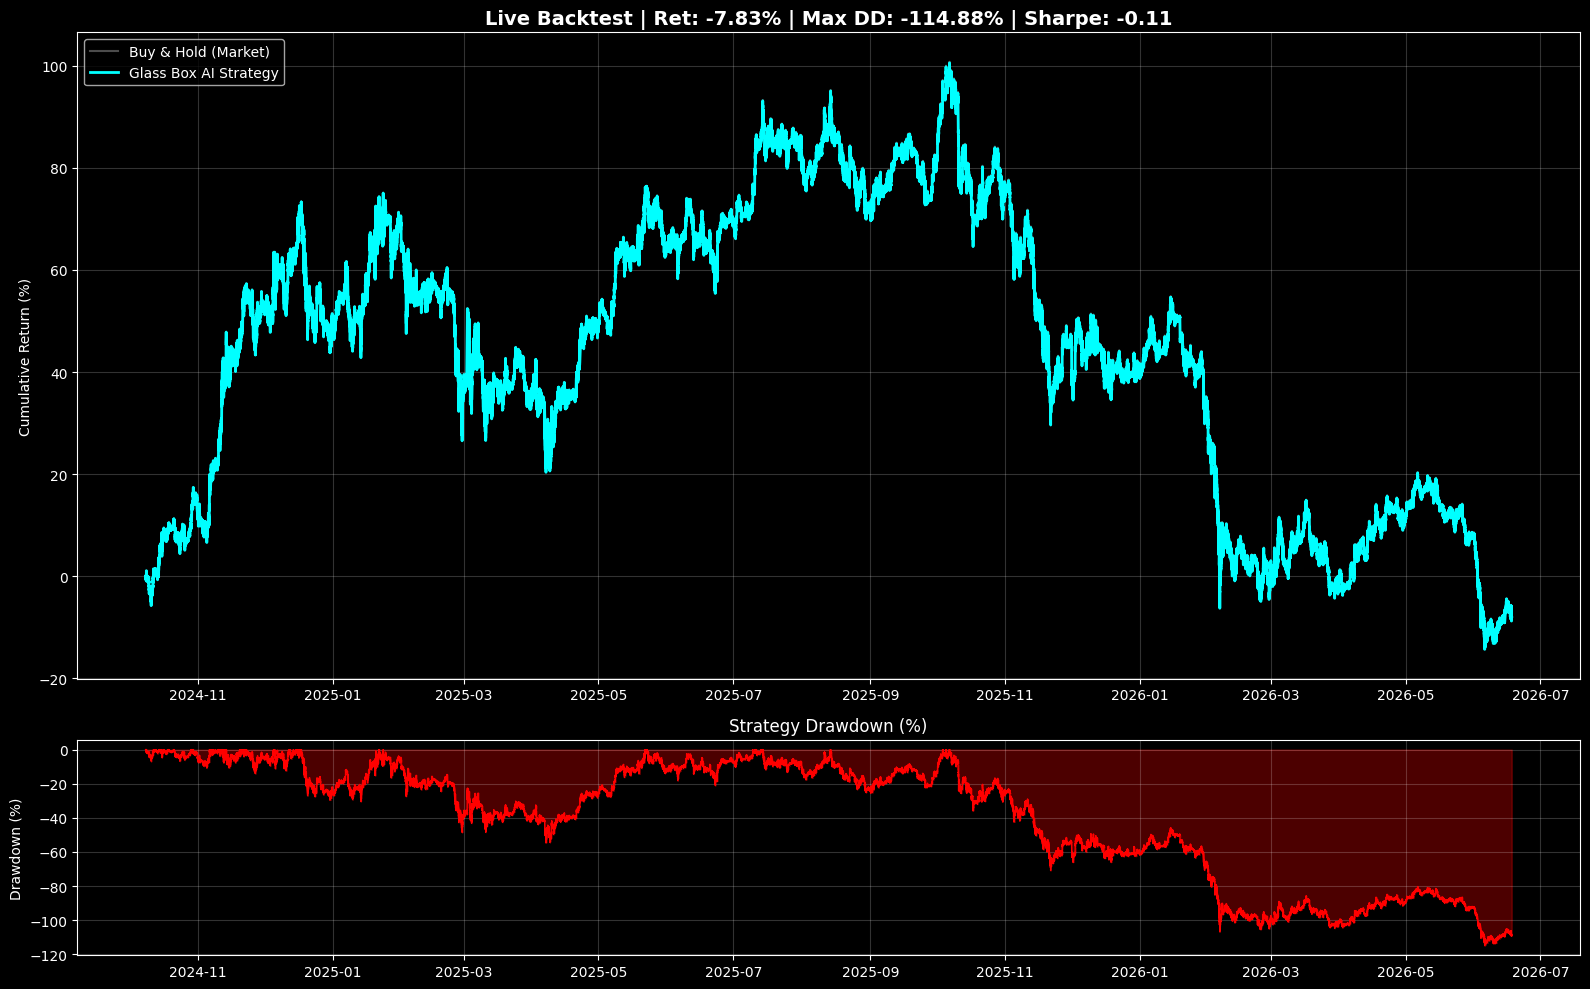

In [18]:
prod_model.eval()
all_probs = []

print("Generating predictions for full validation set...")
with torch.no_grad():
    for X_batch, _ in val_loader:
        X_batch = X_batch.to(device)
        logits = prod_model(X_batch)
        probs = torch.sigmoid(logits).cpu().numpy().flatten()
        all_probs.extend(probs)

all_probs = np.array(all_probs)

backtester = VectorizedBacktester(fee=0.0006, slippage=0.0002)

CONFIDENCE_THRESHOLD = 0.55

bt_df = backtester.run_backtest(df_master, all_probs, threshold=CONFIDENCE_THRESHOLD)

metrics = backtester.calculate_metrics(bt_df)

print("\n--- BACKTEST RESULTS ---")
for k, v in metrics.items():
    if 'Return' in k or 'Drawdown' in k or 'Rate' in k:
        print(f"{k}: {v*100:.2f}%")
    else:
        print(f"{k}: {v}")

BacktestVisualizer.plot_performance(bt_df, metrics)

In [19]:
class StressTester:
    def __init__(self, backtester, df: pd.DataFrame, probs: np.ndarray):
        self.backtester = backtester
        self.df = df
        self.probs = probs

    def run_threshold_sensitivity(self, thresholds: list) -> pd.DataFrame:
        results = []
        for th in thresholds:
            bt_df = self.backtester.run_backtest(self.df, self.probs, threshold=th)
            metrics = self.backtester.calculate_metrics(bt_df)
            metrics['Threshold'] = th
            results.append(metrics)
        return pd.DataFrame(results)

    def run_cost_sensitivity(self, slippages: list, fixed_threshold: float = 0.55) -> pd.DataFrame:
        results = []
        original_slippage = self.backtester.slippage
        for slip in slippages:
            self.backtester.slippage = slip
            bt_df = self.backtester.run_backtest(self.df, self.probs, threshold=fixed_threshold)
            metrics = self.backtester.calculate_metrics(bt_df)
            metrics['Slippage'] = slip
            results.append(metrics)
        self.backtester.slippage = original_slippage
        return pd.DataFrame(results)

class StressVisualizer:
    @staticmethod
    def plot_sensitivities(thresh_df: pd.DataFrame, cost_df: pd.DataFrame):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        ax1.plot(thresh_df['Threshold'], thresh_df['Strategy Return'] * 100, marker='o', color='cyan')
        ax1.set_title('Threshold Sensitivity (Profitability vs. Confidence)', fontsize=12)
        ax1.set_xlabel('Confidence Threshold')
        ax1.set_ylabel('Total Return (%)')
        ax1.grid(True, alpha=0.2)

        ax2.plot(cost_df['Slippage'] * 10000, cost_df['Strategy Return'] * 100, marker='s', color='orange')
        ax2.axhline(0, color='red', linestyle='--', alpha=0.5)
        ax2.set_title('Transaction Cost Sensitivity (Break-even Point)', fontsize=12)
        ax2.set_xlabel('Slippage (BPS - Basis Points)')
        ax2.set_ylabel('Total Return (%)')
        ax2.grid(True, alpha=0.2)

        plt.tight_layout()
        plt.show()

--- STRESS TEST: THRESHOLD DEGRADATION ---


,Threshold,Strategy Return,Max Drawdown,Total Trades
0,0.20,-0.078348,-1.148753,1
1,0.22,-0.078348,-1.148753,1
2,0.24,-0.078348,-1.148753,1
3,0.26,-0.078348,-1.148753,1
4,0.28,-0.078348,-1.148753,1
5,0.30,-0.078348,-1.148753,1
6,0.32,-0.078348,-1.148753,1
7,0.34,-0.078348,-1.148753,1
8,0.36,-0.078348,-1.148753,1
9,0.38,-0.078348,-1.148753,1



--- STRESS TEST: SLIPPAGE DEGRADATION ---


,Slippage,Strategy Return,Max Drawdown,Total Trades
0,0.0001,-0.078256,-1.148868,1
1,0.0003,-0.078440,-1.148638,1
2,0.0005,-0.078625,-1.148409,1
3,0.0007,-0.078809,-1.148179,1
4,0.0009,-0.078993,-1.147950,1
5,0.0011,-0.079177,-1.147720,1
6,0.0013,-0.079361,-1.147490,1
7,0.0015,-0.079546,-1.147261,1
8,0.0017,-0.079730,-1.147032,1
9,0.0019,-0.079914,-1.146802,1


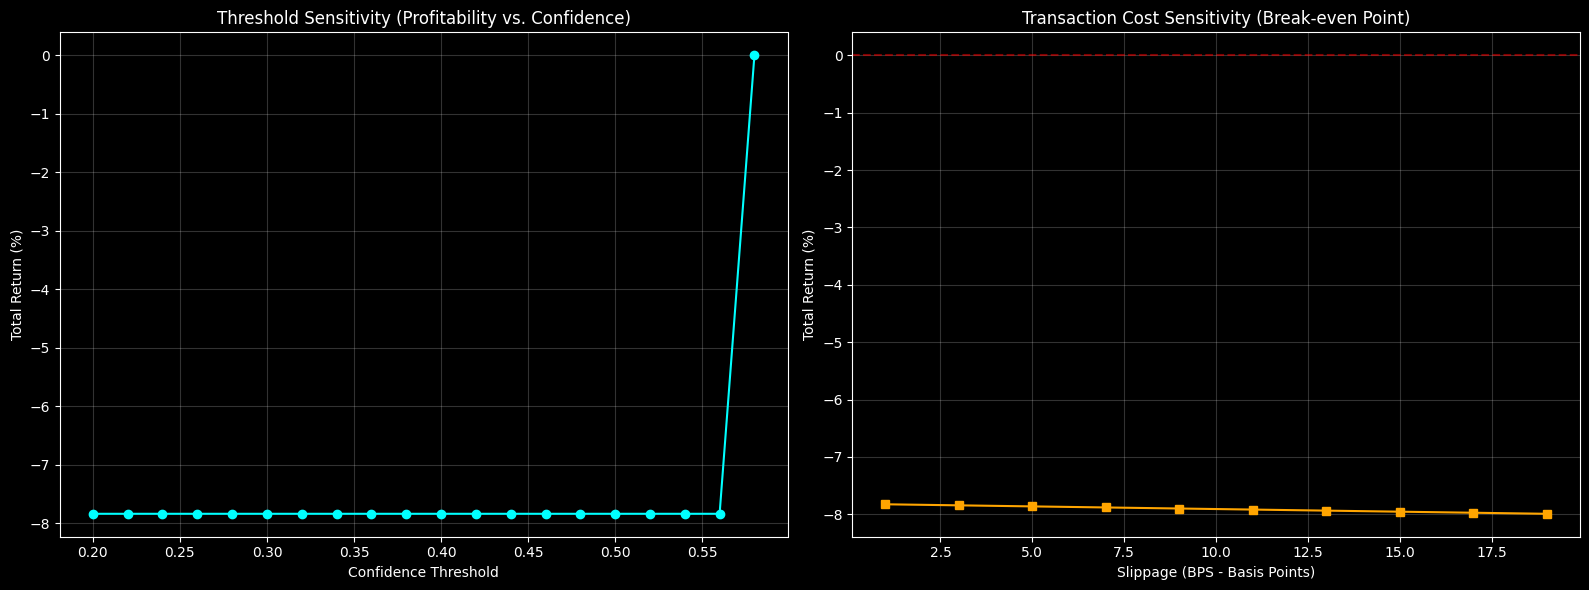

In [20]:
stress_engine = StressTester(backtester, df_master, all_probs)

thresholds_to_test = np.arange(0.20, 0.60, 0.02)
thresh_results = stress_engine.run_threshold_sensitivity(thresholds_to_test)

slippages_to_test = np.arange(0.0001, 0.0020, 0.0002)
cost_results = stress_engine.run_cost_sensitivity(slippages_to_test, fixed_threshold=CONFIDENCE_THRESHOLD)

print("--- STRESS TEST: THRESHOLD DEGRADATION ---")
display(thresh_results[['Threshold', 'Strategy Return', 'Max Drawdown', 'Total Trades']].head(10))

print("\n--- STRESS TEST: SLIPPAGE DEGRADATION ---")
display(cost_results[['Slippage', 'Strategy Return', 'Max Drawdown', 'Total Trades']].head(10))

StressVisualizer.plot_sensitivities(thresh_results, cost_results)